# Predicting Short-Horizon SPY Returns Using Options Market Signals



## Research question:

Do simple signals extracted from the SPY options market contain information about subsequent one-day SPY returns?
This project studies four options-derived signals:

1.   near-30-day at-the-money implied volatility
2.   the daily change in ATM implied volatility
3.   put/call volume ratio
4.   25-delta volatility skew

I construct the signals from daily SPY option-chain data and evaluate their ability to predict subsequent close-to-close SPY returns using chronological expanding-window validation.
The objective is not to maximize backtest performance through extensive feature or model selection, but to test a small set of economically motivated hypotheses while avoiding look-ahead bias and comparing forecasts against a simple zero-return benchmark.

## Summary

This project tests whether simple signals derived from SPY options—near-30-day ATM implied volatility, changes in implied volatility, and put/call volume—predict next-day SPY returns. Using 2024 option-chain data and expanding-window out-of-sample validation, the primary OLS model reduces MSE by approximately 0.58% relative to a zero-return benchmark and achieves an out-of-sample prediction correlation of approximately 0.10. An exploratory 25-delta volatility-skew feature does not improve forecast performance. Overall, the results suggest weak but unstable short-horizon predictive information in these signals.

# Data Loading

We obtained our SPY options price data in 2024 and the underlying SPY price from 1999 to 2025 through the following github repository.

In [3]:
!git clone --depth 1 https://github.com/anahatsingh-ui/options-dataset-hist.git

Cloning into 'options-dataset-hist'...
remote: Enumerating objects: 66, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 66 (delta 0), reused 65 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (66/66), 1.33 GiB | 26.92 MiB/s, done.
Updating files: 100% (61/61), done.


We load the options price and stock price into two pandas dataframes, called


*   options
*   underlying

We load a few lines of options and underlying to get a sense of all the information included in the two dataframes.


In [4]:
import pandas as pd

options = pd.read_parquet("options-dataset-hist/spy/options_2024.parquet")
underlying = pd.read_parquet("options-dataset-hist/spy/underlying_prices.parquet")

print(options.shape)
display(options.head())
display(underlying.head())

print(options.dtypes)

(2292800, 21)


,contract_id,symbol,expiration,strike,type,last,mark,bid,bid_size,ask,...,volume,open_interest,date,implied_volatility,delta,gamma,theta,vega,rho,in_the_money
0,SPY240102C00402000,SPY,2024-01-02,402.0,call,69.97,70.77,70.68,100,70.85,...,130,1,2024-01-02,1.25387,0.99382,0.00056,-0.32882,0.00432,0.01093,0
1,SPY240102P00402000,SPY,2024-01-02,402.0,put,0.02,0.01,0.00,0,0.01,...,0,303,2024-01-02,1.03924,-0.00132,0.00017,-0.05582,0.00108,-0.00002,0
2,SPY240102C00403000,SPY,2024-01-02,403.0,call,68.97,69.78,69.68,100,69.89,...,9,0,2024-01-02,1.25387,0.99313,0.00062,-0.35558,0.00474,0.01095,0
3,SPY240102P00403000,SPY,2024-01-02,403.0,put,0.01,0.01,0.00,0,0.01,...,1,8,2024-01-02,1.02949,-0.00140,0.00018,-0.05839,0.00114,-0.00002,0
4,SPY240102C00404000,SPY,2024-01-02,404.0,call,68.64,68.77,68.68,100,68.85,...,1,1,2024-01-02,1.21485,0.99383,0.00058,-0.32053,0.00431,0.01099,0


,id,symbol,date,open,high,low,close,adjusted_close,volume,dividend_amount,split_coefficient,created_at
0,1,SPY,1999-11-01,136.500000,137.000000,135.562500,135.562500,85.371458,4006500,0.0,1.0,2025-12-15 15:56:25
1,2,SPY,1999-11-02,135.968704,137.250000,134.593704,134.593704,84.761351,6516900,0.0,1.0,2025-12-15 15:56:25
2,3,SPY,1999-11-03,136.000000,136.375000,135.125000,135.500000,85.332098,7222300,0.0,1.0,2025-12-15 15:56:25
3,4,SPY,1999-11-04,136.750000,137.359299,135.765594,136.531204,85.981506,7907500,0.0,1.0,2025-12-15 15:56:25
4,5,SPY,1999-11-05,138.625000,139.109299,136.781204,137.875000,86.827771,7431500,0.0,1.0,2025-12-15 15:56:25


contract_id            object
symbol                 object
expiration             object
strike                float64
type                   object
last                  float64
mark                  float64
bid                   float64
bid_size                int64
ask                   float64
ask_size                int64
volume                  int64
open_interest           int64
date                   object
implied_volatility    float64
delta                 float64
gamma                 float64
theta                 float64
vega                  float64
rho                   float64
in_the_money            int64
dtype: object


A brief inspection of the data tells us that

*   Options price data is available from 2024-01-02 to 2024-12-31
*   Underlying stock price data is available from 1999-11-01 to 2025-12-12



In [5]:
print("Option dates:",options["date"].min(),"to", options["date"].max())
print("Underlying dates:", underlying["date"].min(), "to", underlying["date"].max())


Option dates: 2024-01-02 to 2024-12-31
Underlying dates: 1999-11-01 to 2025-12-12


# Feature Engineering
In this section, we construct the four options-derived features.



## Near-30-Day ATM Implied Volatility
Implied volatility (IV) summarizes the volatility embedded in option prices. I use near-30-day at-the-money (ATM) IV as a measure of the market's current pricing of uncertainty over an approximately one-month horizon.
For each trading date \(t\):
1. Compute days to expiration (DTE) for every available option expiration.
2. Select the expiration whose DTE is closest to 30 calendar days. If two expirations are equally close, select the shorter maturity.
3. Using the contemporaneous unadjusted SPY close $S_t$, select the strike $K_t^*$ closest to spot:
$$
   K_t^* := \arg\min_K |K-S_t|.
$$
4. Average the call and put implied volatilities at that strike:
$$
   IV_t=\frac{IV_{call,t}+IV_{put,t}}{2}.
$$
This produces a simple near-30-day ATM volatility measure. It is not an exact constant-maturity IV because I do not interpolate between adjacent expirations.

In [6]:
options["date"] = pd.to_datetime(options["date"])
options["expiration"] = pd.to_datetime(options["expiration"])
options["dte"] = (options["expiration"] - options["date"]).dt.days
options[["date", "expiration", "dte"]].head()
underlying["date"] = pd.to_datetime(underlying["date"])

In [7]:
def get_atm_iv(date, options, underlying):
    date = pd.Timestamp(date)

    # Options available on this date
    day = options[options["date"] == date].copy()

    # SPY closing price
    spy_price = underlying.loc[underlying["date"] == date, "close"].iloc[0]
    expirations = (day[["expiration", "dte"]].drop_duplicates().copy())

    expirations["distance_from_30"] = abs(expirations["dte"] - 30)

    expirations = expirations.sort_values(["distance_from_30", "dte"])

    target_expiration = expirations.iloc[0]["expiration"]
    chain = day[day["expiration"] == target_expiration].copy()
    strikes = chain["strike"].unique()
    atm_strike = min(strikes, key=lambda K: abs(K - spy_price))
    atm = chain[chain["strike"] == atm_strike]
    atm_iv = atm["implied_volatility"].mean()
    return {
        "date": date,
        "spy_price": spy_price,
        "expiration": target_expiration,
        "dte": (target_expiration - date).days,
        "atm_strike": atm_strike,
        "atm_iv": atm_iv
    }

In [8]:
dates = sorted(options["date"].unique())
results = []
for date in dates:
    try:
        results.append(
            get_atm_iv(date, options, underlying)
        )
    except (IndexError, ValueError):
        pass

atm_iv_daily = pd.DataFrame(results)
atm_iv_daily.head()
atm_iv_daily.describe()


,date,spy_price,expiration,dte,atm_strike,atm_iv
count,252,252.000000,252,252.000000,252.000000,252.000000
mean,2024-07-01 19:37:08.571428608,541.413849,2024-07-31 17:37:08.571428608,29.916667,541.400794,0.130516
min,2024-01-02 00:00:00,467.280000,2024-01-31 00:00:00,27.000000,467.500000,0.092925
25%,2024-04-02 18:00:00,512.712500,2024-05-03 00:00:00,29.000000,512.750000,0.112440
50%,2024-07-02 12:00:00,542.595000,2024-08-01 00:00:00,30.000000,542.250000,0.122195
75%,2024-10-01 06:00:00,570.275000,2024-10-31 06:00:00,31.000000,570.250000,0.142924
max,2024-12-31 00:00:00,607.810000,2025-01-31 00:00:00,32.000000,608.000000,0.292920
std,NaN,36.791905,NaN,1.384677,36.815250,0.026068


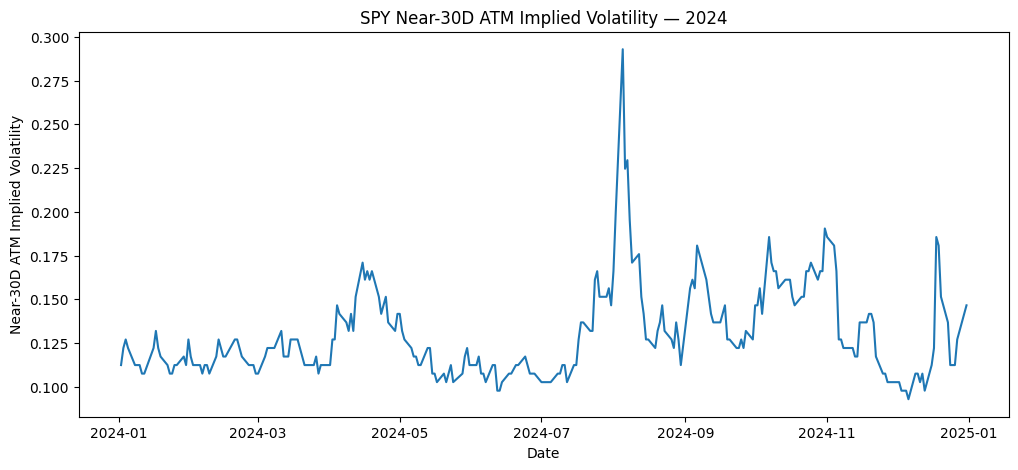

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    atm_iv_daily["date"],
    atm_iv_daily["atm_iv"]
)

plt.xlabel("Date")
plt.ylabel("Near-30D ATM Implied Volatility")
plt.title("SPY Near-30D ATM Implied Volatility — 2024")

plt.show()

Near-30-day ATM IV varies substantially over the year, with several periods of elevated implied volatility. The supplied IV values are discretized, producing some visible stair-stepping; this is treated as a limitation of the third-party dataset.

## Change in ATM IV

The IV level measures the current state of implied uncertainty, while its daily change captures the repricing of that uncertainty. They're related but not equivalent. In fact, we later found their correlation was only about 0.25, so empirically they aren't redundant either.

I therefore construct
$$
\Delta IV_t=IV_t-IV_{t-1}.
$$
The first observation is missing because no previous trading-day IV is available.

In [10]:
atm_iv_daily["atm_iv_change"] = (atm_iv_daily["atm_iv"].diff())
atm_iv_daily[["date", "atm_iv", "atm_iv_change"]].head(10)

,date,atm_iv,atm_iv_change
0,2024-01-02,0.11244,NaN
1,2024-01-03,0.12219,0.00975
2,2024-01-04,0.12707,0.00488
3,2024-01-05,0.12219,-0.00488
4,2024-01-08,0.11244,-0.00975
5,2024-01-09,0.11244,0.00000
6,2024-01-10,0.11244,0.00000
7,2024-01-11,0.10756,-0.00488
8,2024-01-12,0.10756,0.00000
9,2024-01-16,0.12219,0.01463


## Put/Call Volume Ratio

The put/call volume ratio (PCR) measures relative trading activity in put and call options:
$$
PCR_t=\frac{\text{Put Volume}_t}{\text{Call Volume}_t}.
$$
A larger value indicates greater put trading volume relative to call trading volume. However, PCR should not be interpreted mechanically as a bearish-sentiment measure because option volume can reflect hedging, spreads, volatility trades, and market-making activity.
Rather than aggregate all SPY options, I restrict the calculation to contracts with 8–60 days to expiration and absolute delta between 0.2 and 0.8. This excludes very short-dated contracts and very low/high-delta contracts, which represent distinct trading regimes and dominate aggregate option volume.

In [11]:
dte_bins = [0, 7, 30, 60, 90, float("inf")]
dte_labels = ["0-7", "8-30", "31-60", "61-90", ">90"]

options["dte_bucket"] = pd.cut(
    options["dte"],
    bins=dte_bins,
    labels= dte_labels,
    right=True,
    include_lowest=True
)

options["dte_bucket"].value_counts().sort_index()
volume_by_dte = (options.groupby("dte_bucket", observed=True)["volume"].sum())
volume_by_dte

,volume
dte_bucket,
0-7,1591422512
8-30,188639002
31-60,96111195
61-90,32677065
>90,47686375


Approximately 81% of total option volume occurs in contracts with 0–7 DTE. I exclude these contracts from the primary PCR specification so that the feature is not dominated by very short-dated option activity.

In [12]:
options["abs_delta"] = options["delta"].abs()
delta_bins = [0, 0.1, 0.2, 0.4, 0.6, 0.8, 1]

delta_labels = [
    "0-.10",
    ".10-.20",
    ".20-.40",
    ".40-.60",
    ".60-.80",
    ".80-1"
]

options["delta_bucket"] = pd.cut(
    options["abs_delta"],
    bins=delta_bins,
    labels=delta_labels,
    include_lowest=True
)
volume_by_delta = (
    options
    .groupby("delta_bucket", observed=True)["volume"]
    .sum()
)

volume_by_delta

,volume
delta_bucket,
0-.10,849587998
.10-.20,192980445
.20-.40,289274053
.40-.60,252062982
.60-.80,149601098
.80-1,223029573


Now we combine dte and delta filter, and construct the actual put/call ratio feature.

In [13]:
filtered_options = options[options["dte"].between(8, 60) & options["abs_delta"].between(0.2, 0.8)]
cp_volume_table = filtered_options.groupby(["date", "type"])["volume"].sum().unstack()
cp_volume_table["put_call_ratio"] = cp_volume_table["put"]/cp_volume_table["call"]
print(cp_volume_table["put_call_ratio"].describe())
cp_volume_table["put_call_ratio"].sort_values().head()
cp_volume_table["put_call_ratio"].sort_values(ascending=True).head()

count    252.000000
mean       1.229252
std        0.521162
min        0.499207
25%        0.864660
50%        1.121062
75%        1.430755
max        4.467517
Name: put_call_ratio, dtype: float64


,put_call_ratio
date,
2024-07-10,0.499207
2024-01-19,0.537487
2024-02-29,0.554273
2024-07-02,0.600854
2024-01-10,0.608873


The 8–60 DTE and $0.2\le|\Delta|\le0.8 $ filters are fixed modeling choices intended to define a reasonably liquid, non-extreme option universe; they are not selected by optimizing subsequent return-prediction performance.

## 25-Delta Volatility Skew

ATM implied volatility measures the overall level of option-implied uncertainty, but it does not capture whether downside and upside options are priced differently. To measure this asymmetry, I construct a near-30-day 25-delta volatility skew:
$$
Skew_t
=
IV_{\Delta\approx-0.25,t}^{put}
-
IV_{\Delta\approx+0.25,t}^{call}.
$$
For each trading day, I use the same near-30-day expiration methodology as for ATM IV. Within that expiration, I select the put whose delta is closest to \(-0.25\) and the call whose delta is closest to \(+0.25\).
Positive skew means that the selected downside put has higher implied volatility than the corresponding upside call. This may reflect asymmetric pricing of downside versus upside risk, but should not be interpreted mechanically as a directional market forecast.

In [14]:
def get_skew(date, options):
    date = pd.Timestamp(date)

    day = options[
        options["date"] == date
    ].copy()

    # Find the expiration closest to 30 DTE,
    # breaking ties in favor of shorter DTE
    expirations = (
        day[["expiration", "dte"]]
        .drop_duplicates()
        .copy()
    )

    expirations["distance_from_30"] = abs(expirations["dte"] - 30)
    expirations = expirations.sort_values(["distance_from_30", "dte"])
    target_expiration = expirations.iloc[0]["expiration"]

    chain = day[day["expiration"] == target_expiration].copy()

    calls = chain[chain["type"] == "call"]
    puts = chain[chain["type"] == "put"]

    # Closest to +0.25
    call_25 = calls.loc[(calls["delta"]-0.25).abs().idxmin()]

    # Closest to -0.25
    put_25 = puts.loc[(puts["delta"] + 0.25).abs().idxmin()]

    skew = put_25["implied_volatility"] - call_25["implied_volatility"]

    return {
        "date": date,
    "expiration": target_expiration,
    "call_strike": call_25["strike"],
    "call_delta": call_25["delta"],
    "call_iv": call_25["implied_volatility"],
    "put_strike": put_25["strike"],
    "put_delta": put_25["delta"],
    "put_iv": put_25["implied_volatility"],
    "skew": skew
    }

In [15]:
valid_dates = underlying[
    underlying["date"].dt.year == 2024
]["date"].unique()
skew_results = []

for date in valid_dates:
    result = get_skew(date, options)
    skew_results.append(result)

skew_daily = pd.DataFrame(skew_results)
skew_daily = skew_daily.sort_values("date").reset_index(drop=True)

Quality control checks:

In [16]:
skew_daily["skew"].describe()

,skew
count,252.000000
mean,0.039256
std,0.019078
min,-0.019510
25%,0.029260
50%,0.039020
75%,0.048780
max,0.126820


In [17]:
skew_daily["call_delta_error"] = (skew_daily["call_delta"] - 0.25).abs()
skew_daily["put_delta_error"] = (skew_daily["put_delta"] + 0.25).abs()
skew_daily[["call_delta_error", "put_delta_error"]].describe()

,call_delta_error,put_delta_error
count,252.000000,252.000000
mean,0.008554,0.003837
std,0.010687,0.003323
min,0.000060,0.000010
25%,0.002245,0.001672
50%,0.005065,0.003195
75%,0.008868,0.005257
max,0.062040,0.023020


The selected contracts are generally close to the target deltas of \(+0.25\) and \(-0.25\), supporting the use of the resulting series as an approximate 25-delta skew measure.

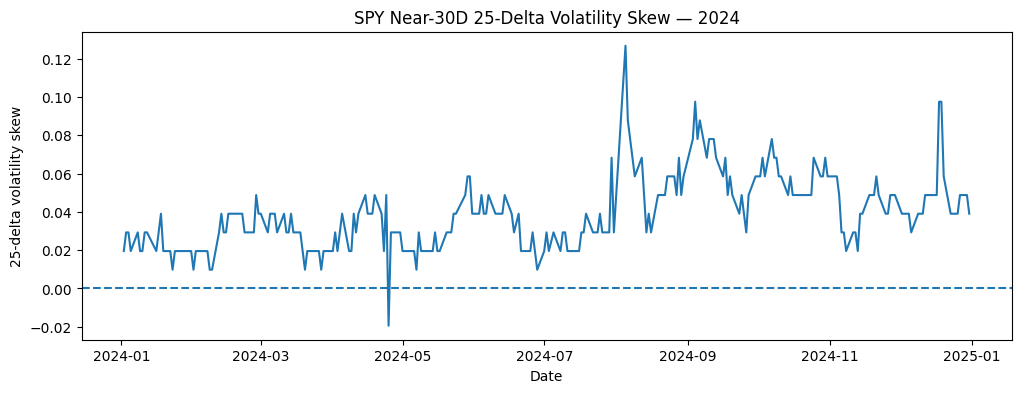

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(skew_daily["date"], skew_daily["skew"])
plt.axhline(0, linestyle="--")
plt.xlabel("Date")
plt.ylabel("25-delta volatility skew")
plt.title("SPY Near-30D 25-Delta Volatility Skew — 2024")
plt.show()

The skew is positive on most trading days, indicating that 25-delta puts generally carry higher implied volatility than comparable 25-delta calls. The series exhibits visible stair-stepping because the source dataset reports implied volatility on a relatively coarse grid. Despite this discretization, skew varies meaningfully over time.

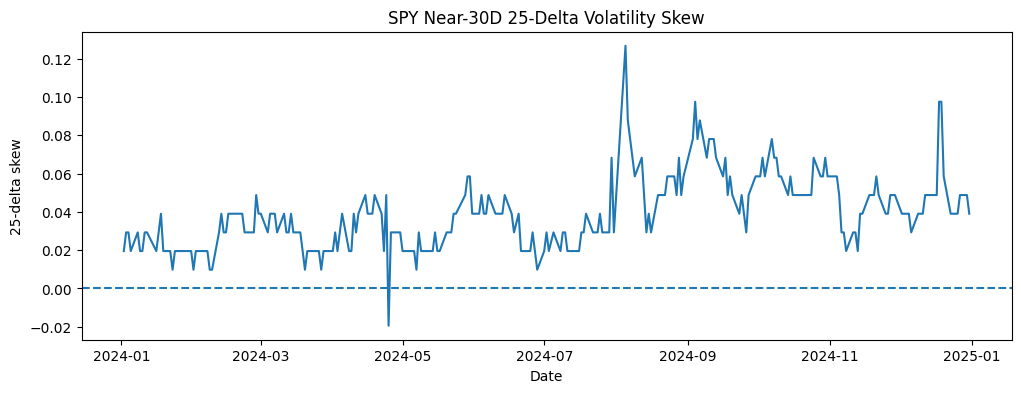

In [19]:
plt.figure(figsize=(12, 4))
plt.plot(skew_daily["date"], skew_daily["skew"])
plt.axhline(0, linestyle="--")
plt.xlabel("Date")
plt.ylabel("25-delta skew")
plt.title("SPY Near-30D 25-Delta Volatility Skew")
plt.show()

# Target Construction and Modeling Dataset



## Prediction Target

The objective is to test whether option-market information observed on trading day \(t\) contains information about the subsequent SPY return. I define the prediction target as the next trading day's close-to-close return:
$$
r_{t+1}=\frac{P_{t+1}}{P_t}-1,
$$
where \(P_t\) is SPY's adjusted closing price.
Adjusted close is used for the return calculation because it accounts for distributions and stock splits, producing a more consistent measure of investment returns over time. In contrast, the contemporaneous unadjusted close is used when identifying ATM options because moneyness should be based on the actual underlying price observed on that date.

## Construct the target

In [20]:
spy = underlying.sort_values("date")[underlying["date"]>="2024-01-02"].copy()
spy["return"] = spy["adjusted_close"].pct_change()
spy["next_day_return"] = spy["return"].shift(-1)
spy.head(5)

,id,symbol,date,open,high,low,close,adjusted_close,volume,dividend_amount,split_coefficient,created_at,return,next_day_return
6080,6081,SPY,2024-01-02,472.16,473.67,470.49,472.65,462.619009,123007793,0.0,1.0,2025-12-15 15:56:25,NaN,-0.008167
6081,6082,SPY,2024-01-03,470.43,471.19,468.17,468.79,458.840929,103585866,0.0,1.0,2025-12-15 15:56:25,-0.008167,-0.003221
6082,6083,SPY,2024-01-04,468.30,470.96,467.05,467.28,457.362976,84232169,0.0,1.0,2025-12-15 15:56:25,-0.003221,0.001370
6083,6084,SPY,2024-01-05,467.49,470.44,466.43,467.92,457.989393,85553758,0.0,1.0,2025-12-15 15:56:25,0.001370,0.014276
6084,6085,SPY,2024-01-08,468.43,474.75,468.30,474.60,464.527625,74879074,0.0,1.0,2025-12-15 15:56:25,0.014276,-0.001517


## Merge the features

In [21]:
model_data = atm_iv_daily.merge(
    cp_volume_table[["put_call_ratio"]],
    on= "date",
    how= "inner"
)

model_data = model_data.merge(
    skew_daily[["date", "skew"]],
    on= "date",
    how="inner"
)
model_data = model_data.merge(
    spy[["date", "next_day_return"]],
    on="date",
    how="inner"
)
model_data = (
    model_data
    .sort_values("date")
    .reset_index(drop=True)
)

model_data.head()
print(model_data.shape)
print(model_data.isna().sum())
model_data = model_data.dropna().copy()


(252, 10)
date               0
spy_price          0
expiration         0
dte                0
atm_strike         0
atm_iv             0
atm_iv_change      1
put_call_ratio     0
skew               0
next_day_return    0
dtype: int64


In [22]:
cols = [
    "date",
    "atm_iv",
    "atm_iv_change",
    "put_call_ratio",
    "skew",
    "next_day_return"
]
model_data = model_data[cols].copy()
model_data.head()


,date,atm_iv,atm_iv_change,put_call_ratio,skew,next_day_return
1,2024-01-03,0.12219,0.00975,1.743854,0.02926,-0.003221
2,2024-01-04,0.12707,0.00488,1.600058,0.02926,0.001370
3,2024-01-05,0.12219,-0.00488,1.131229,0.01951,0.014276
4,2024-01-08,0.11244,-0.00975,0.694244,0.02927,-0.001517
5,2024-01-09,0.11244,0.00000,0.752153,0.01951,0.005655


## Timing assumption

**Timing convention.**
Options features are constructed from daily end-of-day observations. The analysis tests whether day-\(t\) options-market information is statistically associated with the subsequent close-to-close SPY return. Because precise intraday timestamps for the option-chain observations are unavailable, the analysis should be interpreted as a predictive statistical study rather than an immediately executable closing-price trading strategy.

# Exploratory Data Analysis



## Summary statistics

The predictors operate on different numerical scales. ATM IV and skew are expressed in volatility units, ATM IV change measures daily changes in those units, and the put/call ratio is dimensionless. Next-day SPY returns are generally small relative to the variation in the predictors. These scale differences should be considered when interpreting regression coefficient magnitudes.

In [23]:
feature_cols = [
    "atm_iv",
    "atm_iv_change",
    "put_call_ratio",
    "skew",
    "next_day_return"
]

model_data[feature_cols].describe()

,atm_iv,atm_iv_change,put_call_ratio,skew,next_day_return
count,251.000000,251.000000,251.000000,251.000000,251.000000
mean,0.130588,0.000136,1.229759,0.039335,0.000962
std,0.026095,0.013279,0.522141,0.019075,0.007904
min,0.092925,-0.068290,0.499207,-0.019510,-0.029804
25%,0.112440,-0.004880,0.864233,0.029260,-0.002740
50%,0.122195,0.000000,1.122063,0.039020,0.001093
75%,0.144143,0.004880,1.431786,0.048780,0.005773
max,0.292920,0.092680,4.467517,0.126820,0.024866


## Correlation matrix


In [24]:
corr_matrix = model_data[feature_cols].corr()
corr_matrix

,atm_iv,atm_iv_change,put_call_ratio,skew,next_day_return
atm_iv,1.000000,0.254045,0.604321,0.667000,0.098304
atm_iv_change,0.254045,1.000000,0.508520,0.204225,-0.043799
put_call_ratio,0.604321,0.508520,1.000000,0.528270,0.097980
skew,0.667000,0.204225,0.528270,1.000000,0.036762
next_day_return,0.098304,-0.043799,0.097980,0.036762,1.000000


The options-derived features exhibit moderate correlations with one another. ATM IV is particularly correlated with skew (0.67) and PCR (0.60), suggesting that periods of elevated implied volatility also tend to coincide with greater downside volatility asymmetry and relatively greater put activity.
In contrast, the individual correlations between each feature and next-day SPY returns are weak. ATM IV and PCR have correlations of approximately 0.10 with next-day returns, while ΔIV and skew have correlations closer to zero. These are descriptive in-sample relationships and should not be interpreted as evidence of out-of-sample predictability.

## Feature versus return scatter plots

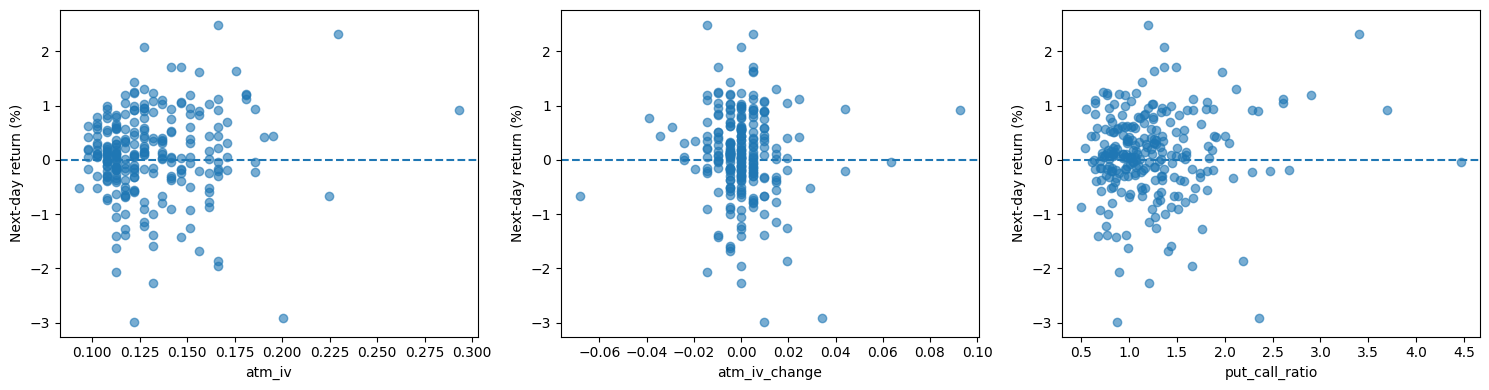

In [25]:
import matplotlib.pyplot as plt

primary_features = [
    "atm_iv",
    "atm_iv_change",
    "put_call_ratio"
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feature in zip(axes, primary_features):
    ax.scatter(
        model_data[feature],
        100 * model_data["next_day_return"],
        alpha=0.6
    )
    ax.axhline(0, linestyle="--")
    ax.set_xlabel(feature)
    ax.set_ylabel("Next-day return (%)")

plt.tight_layout()
plt.show()

The scatter plots show substantial noise and no strong univariate linear relationship between any individual predictor and next-day return. ATM IV takes visibly discrete values because of the quantization of implied volatility in the source dataset.

## Next-day return distribution

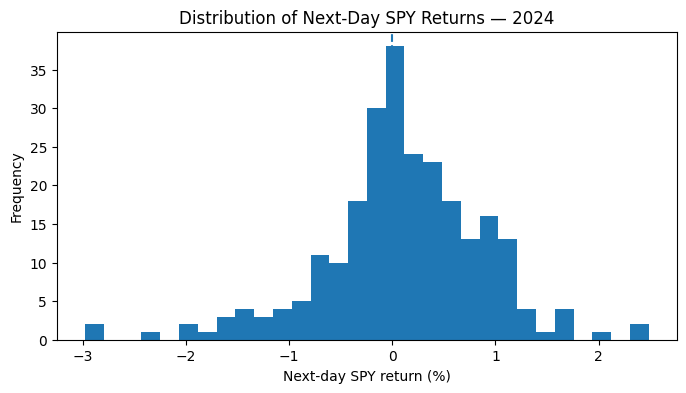

In [26]:
plt.figure(figsize=(8, 4))

plt.hist(
    100 * model_data["next_day_return"],
    bins=30
)

plt.axvline(0, linestyle="--")

plt.xlabel("Next-day SPY return (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Next-Day SPY Returns — 2024")

plt.show()

**Remark**: Next-day returns are concentrated around zero, illustrating why a zero-return forecast provides a meaningful simple benchmark.

# Baseline and Validation Design



## Zero-Return Baseline
Daily equity returns are noisy and concentrated around zero. A forecasting model should therefore be evaluated relative to a simple benchmark rather than by prediction error alone. I use a zero-return forecast,
$$
\hat{r}_{t+1}^{baseline}=0,
$$
which gives
$$
MSE_{baseline}
=
\frac{1}{N}\sum_{t=1}^{N}r_{t+1}^2.
$$
A model that does not improve upon this benchmark provides little evidence that its additional complexity contributes useful forecasting information.

## Train/Test split and Exanding-Window design

**Chronological Validation**: Because the observations form a time series, randomly splitting dates into training and test sets can allow future observations to influence a model used to predict earlier observations. Instead, I preserve chronological ordering so that every prediction is generated using only information available before the prediction period.

More precisely, I use an expanding-window validation procedure beginning in July. For each test month, the model is estimated using all observations from the beginning of the year through the preceding month. The fitted model then generates predictions for the next month. Afterward, that month's observations are incorporated into the training set for the subsequent forecast.
This mimics a sequential forecasting setting while retaining as much training data as possible given the relatively small one-year sample.

## Define the primary model
The primary specification uses three predictors: ATM IV, the daily change in ATM IV, and the filtered put/call volume ratio. I estimate the model using ordinary least squares (OLS):
$$r_{t+1}
=
\beta_0+
\beta_1 IV_t+
\beta_2\Delta IV_t+
\beta_3PCR_t+
\epsilon_{t+1}.$$
Volatility skew is considered separately as an exploratory extension.

In [65]:
import statsmodels.api as sm

def expanding_window_evaluation(model_data, features, target = "next_day_return"):
  results = []
  all_predictions = []

  for test_month in range(7, 13):

      month_train = model_data[
          model_data["month"] < test_month
      ].copy()

      month_test = model_data[
          model_data["month"] == test_month
      ].copy()

      X_train = month_train[features]
      y_train = month_train["next_day_return"]

      X_test = month_test[features]
      y_test = month_test["next_day_return"]

      X_train = sm.add_constant(X_train)
      X_test = sm.add_constant(X_test)

      model = sm.OLS(y_train, X_train).fit()
      pred = model.predict(X_test)

      model_mse = ((y_test - pred) ** 2).mean()
      baseline_mse = (y_test ** 2).mean()
      pred_corr = pred.corr(y_test)
      result = {
          "month": test_month,
          "n_test": len(X_test),
          "model_mse": model_mse,
          "baseline_mse": baseline_mse,
          "prediction_corr": pred_corr
      }

      for feature in features:
        result["beta_" + feature] = model.params[feature]

      results.append(result)

      month_predictions = pd.DataFrame({
      "date": month_test["date"].values,
      "actual": y_test.values,
      "predicted": pred.values })

      all_predictions.append(month_predictions)

  monthly_results = pd.DataFrame(results)

  oos_predictions = pd.concat(
    all_predictions,
    ignore_index=True)

  return monthly_results, oos_predictions


In [66]:
features = [
    "atm_iv",
    "atm_iv_change",
    "put_call_ratio"
]
model_data["month"] = (model_data["date"].dt.month)

monthly_results, oos_predictions = expanding_window_evaluation(model_data,features)


# Primary Model Results

## Aggregate out-of-sample performance

In [67]:
def combined_mse(oos_predictions):
  combined_model_mse = ((oos_predictions["actual"]
      - oos_predictions["predicted"]) ** 2).mean()

  combined_baseline_mse = (
      oos_predictions["actual"] ** 2).mean()
  return combined_model_mse, combined_baseline_mse

def combined_corr(oos_predictions):
  combined_corr = (
      oos_predictions["predicted"]
      .corr(oos_predictions["actual"]))
  return combined_corr


In [68]:
primary_mse, baseline_mse = combined_mse(oos_predictions)
primary_corr = combined_corr(oos_predictions)
print("Model MSE:", primary_mse)
print("Baseline MSE:", baseline_mse)
print("Prediction correlation:", primary_corr)

Model MSE: 7.915404591677118e-05
Baseline MSE: 7.96194425216993e-05
Prediction correlation: 0.09822946513491364


In [69]:
mse_improvement = (baseline_mse - primary_mse) / baseline_mse

print(f"MSE improvement: {100*mse_improvement:.2f}%")

MSE improvement: 0.58%


**Out-of-sample performance.**
Across the July–December expanding-window forecasts, the three-feature OLS model achieves a combined MSE of approximately $ 7.92\times10^{-5} $, compared with $ 7.96\times10^{-5} $ for the zero-return benchmark. This corresponds to an MSE reduction of approximately 0.58%.
The correlation between predicted and realized out-of-sample returns is approximately 0.10. Thus, the options-derived signals exhibit a weak positive association with subsequent returns, but the improvement in forecast accuracy relative to the simple benchmark is very small.

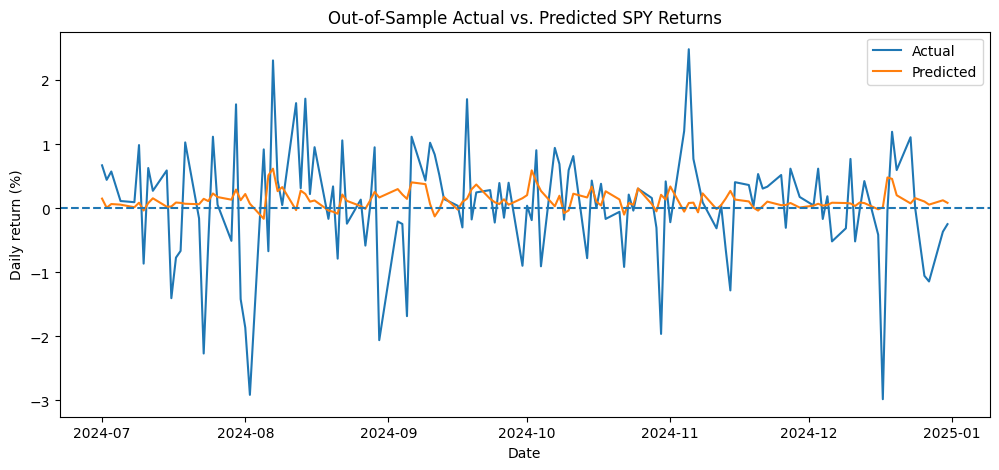

In [71]:
plt.figure(figsize=(12, 5))

plt.plot(
    oos_predictions["date"],
    100 * oos_predictions["actual"],
    label="Actual"
)

plt.plot(
    oos_predictions["date"],
    100 * oos_predictions["predicted"],
    label="Predicted"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Date")
plt.ylabel("Daily return (%)")
plt.title(
    "Out-of-Sample Actual vs. Predicted SPY Returns"
)

plt.legend()
plt.show()

The model predictions vary over a substantially narrower range than realized daily returns. The linear model captures only a small component of daily return variation and does not reproduce large realized moves.

## Monthly Performance

In [70]:
monthly_results

,month,n_test,model_mse,baseline_mse,prediction_corr,beta_atm_iv,beta_atm_iv_change,beta_put_call_ratio
0,7,22,0.000085,0.000087,0.271591,0.002983,-0.049560,0.002134
1,8,22,0.000145,0.000150,0.181928,-0.027272,-0.081944,0.003711
2,9,20,0.000054,0.000054,-0.052012,-0.027410,-0.059692,0.004146
3,10,23,0.000047,0.000044,0.062809,-0.016034,-0.050291,0.003467
4,11,20,0.000064,0.000061,-0.387703,-0.013876,-0.026854,0.002880
5,12,21,0.000077,0.000079,0.364793,0.009572,-0.035370,0.001661


Performance varies substantially across test months. The model modestly outperforms the baseline in some months, approximately matches it in others, and underperforms in others. Monthly prediction correlations also vary substantially in sign and magnitude. Given the small number of observations per month, these individual correlations should be interpreted cautiously, but collectively they indicate that the predictive relationship is not stable over time.

## Coefficient stability

In [74]:
monthly_results[["month"]+["beta_"+feature for feature in features]]

,month,beta_atm_iv,beta_atm_iv_change,beta_put_call_ratio
0,7,0.002983,-0.049560,0.002134
1,8,-0.027272,-0.081944,0.003711
2,9,-0.027410,-0.059692,0.004146
3,10,-0.016034,-0.050291,0.003467
4,11,-0.013876,-0.026854,0.002880
5,12,0.009572,-0.035370,0.001661


The fitted coefficients on ΔIV and PCR retain consistent signs across the expanding-window estimates, while the ATM-IV coefficient changes sign. However, the training windows overlap substantially, so these estimates are not independent evidence of coefficient stability. Moreover, consistent coefficient signs do not necessarily imply useful out-of-sample predictive power.

**In conclusion,**  the options signals showed a weak positive out-of-sample relationship with next-day SPY returns, but the three-feature model improved MSE over a zero-return benchmark by only about 0.6%, and performance varied considerably across months.

# Volatility-Skew Extension

## Motivation

**Volatility-Skew Extension** The primary model uses ATM IV, the change in ATM IV, and the put/call volume ratio. As an exploratory extension, I test whether the 25-delta volatility skew constructed earlier contains additional information about subsequent returns.
The extended specification is
$$
r_{t+1}
=
\beta_0+\beta_1IV_t+\beta_2\Delta IV_t
+\beta_3PCR_t+\beta_4Skew_t+\epsilon_{t+1}.
$$ Because skew is moderately correlated with both ATM IV and PCR, the relevant question is not simply whether skew is individually correlated with next-day returns, but whether it improves out-of-sample forecasts conditional on the existing predictors.

In [75]:
extended_features = [
    "atm_iv",
    "atm_iv_change",
    "put_call_ratio",
    "skew"
]
skew_results, skew_predictions = expanding_window_evaluation(model_data,extended_features)


In [76]:
skew_mse, skew_baseline_mse = combined_mse(skew_predictions)
skew_corr = combined_corr(skew_predictions)

agg_mse_corr = {'Model': ['Zero-return baseline', 'Primary', "Add 25-Delta Skew"],
'OOS MSE': [baseline_mse, primary_mse, skew_mse],
'OOS correlation': [None, primary_corr, skew_corr]}

comparison_mse_corr = pd.DataFrame(agg_mse_corr)
display(comparison_mse_corr)

skew_mse_improvement = (baseline_mse - skew_mse)/baseline_mse
print("Adding the volatility skew improves the oos mse over the baseline by: ", skew_mse_improvement)


,Model,OOS MSE,OOS correlation
0,Zero-return baseline,0.000080,NaN
1,Primary,0.000079,0.098229
2,Add 25-Delta Skew,0.000079,0.085989


Adding the volatility skew improves the oos mse over the baseline by:  0.004407972303032147


Adding 25-delta skew does not improve out-of-sample performance. Combined MSE increases slightly from $7.915\times10^{-5}$ to $7.927\times10^{-5}$, while prediction correlation decreases from 0.098 to 0.086. Thus, although skew is economically interpretable, it does not provide incremental forecasting improvement in this sample.

## Skew coefficient

In [77]:
skew_results[["month", "beta_skew"]]

,month,beta_skew
0,7,-0.033703
1,8,-0.001394
2,9,-0.029998
3,10,-0.026758
4,11,-0.029635
5,12,-0.021628


The fitted skew coefficient is negative in each expanding-window regression. Conditional on the other predictors, higher downside-versus-upside implied-volatility skew is therefore associated with lower next-day returns in these fitted samples. However, this coefficient pattern does not translate into improved out-of-sample forecast accuracy.
Furthermore, successive expanding-window estimates share most of their training observations, so the six negative coefficients should not be interpreted as six independent confirmations of the relationship.

**In conclusion,** the additional skew feature increases model complexity without improving out-of-sample performance, I retain the three-feature specification as the primary model.

# Limitations and Conclusion


## Key findings

This project investigates whether simple signals extracted from the SPY options market contain information about subsequent one-day SPY returns. I construct three primary predictors—near-30-day ATM implied volatility, the daily change in ATM implied volatility, and a filtered put/call volume ratio—and evaluate a linear forecasting model using expanding-window out-of-sample validation.
The primary model achieves an out-of-sample MSE of approximately $7.92\times10^{-5}$, compared with $7.96\times10^{-5}$ for a zero-return benchmark, corresponding to an improvement of approximately 0.58%. The correlation between predicted and realized returns is approximately 0.10. Performance varies substantially across individual test months, indicating that the predictive relationship is weak and unstable.
As an exploratory extension, I add 25-delta volatility skew. Although its estimated coefficient is consistently negative across the expanding-window regressions, adding skew does not improve out-of-sample performance. I therefore retain the simpler three-feature specification as the primary model.
Overall, the results provide limited evidence that these options-market variables contain short-horizon return information, but the economic and statistical magnitude of the forecasting improvement is small.

## Limitations
There are severeal limitations of this project that comes from data accessibility, data quality, etc. We are going to address them in this subsection one by one.



1.   **Short sample period.** The analysis uses only 2024 data, providing approximately 250 daily observations and 128 expanding-window out-of-sample predictions. This limits statistical power and makes it difficult to determine whether the observed relationships persist across different market regimes.

2.   **Coarse implied-volatility data.** The supplied implied-volatility field is relatively coarse, with repeated values and visible stair-step behavior. This discretization may reduce the information contained in ATM IV and volatility-skew measures.

3.   **Timing and executability.** Options features are constructed from daily end-of-day observations, but precise intraday timestamps are unavailable. The analysis therefore tests statistical predictability of subsequent close-to-close returns rather than the performance of an immediately executable trading strategy.

4.   **Simplified feature definitions.** Near-30-day ATM IV is constructed using the available expiration closest to 30 days and the strike closest to spot, rather than interpolating to an exact constant maturity or using a forward-based ATM definition. Similarly, 25-delta skew is obtained from the available contracts closest to the target deltas rather than through interpolation.

## Next Steps
With the limitations being identified, one can try the following things as next steps.


1.   **Evaluate across multiple market regimes.** Freeze the current feature definitions and validation procedure, then test them on additional years of data to determine whether the weak predictive relationship persists.
2.   **Improve volatility-surface construction.** Construct exact constant-maturity ATM volatility and delta-based skew using interpolation across expirations and strikes rather than nearest-contract approximations.
3.  **Study alternative prediction targets.** Options signals may contain more information about future volatility or tail risk than about the conditional mean of next-day returns. Testing realized volatility or large-move probabilities would provide a natural extension.

## Final Conslusion
This study finds that simple SPY options-market signals have, at most, modest predictive value for next-day SPY returns in the 2024 sample. The three-feature model slightly outperforms a zero-return benchmark in expanding-window evaluation, but the improvement is small and varies considerably across time. Adding volatility skew does not improve forecast accuracy. The results therefore illustrate both the potential information content of options markets and the difficulty of converting economically motivated signals into robust short-horizon return forecasts.